In [ ]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

plt.style.use("seaborn-v0_8")

# Configure Matplotlib for LaTeX-style formatting
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    # Explicitly set serif fonts to avoid "Generic family 'serif' not found" errors
    # if "Computer Modern Roman" is missing from the system.
    "font.serif": ["DejaVu Serif", "Bitstream Vera Serif", "Computer Modern Roman", "New Century Schoolbook", "Century Schoolbook L", "Utopia", "ITC Bookman", "Bookman", "Nimbus Roman No9 L", "Times New Roman", "Times", "Palatino", "Charter", "serif"],
    "mathtext.fontset": "cm",   # Use Computer Modern (LaTeX style) for math
    "axes.labelsize": 14,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.titlesize": 14
})

pd.set_option('display.max_rows', 50)

In [ ]:
# Select the run directory
from pathlib import Path


def find_project_root(start: Path, marker: str = "lightning_logs") -> Path:
    """Walk upward from start until a folder containing `marker` is found."""
    for p in [start] + list(start.parents):
        if (p / marker).exists():
            return p
    raise FileNotFoundError(f"Could not find `{marker}` above {start}")

# Start search from the current working directory (usually the notebook folder)
project_root = find_project_root(Path.cwd())
log_root = project_root / "lightning_logs"
run_label = "scarfGNN_Dataset10percent_test20260211"  # change to your run folder under lightning_logs
version = None  # set to an int like 0, 1, ...; leave None to pick the latest version

run_dir = log_root / run_label
if not run_dir.exists():
    raise FileNotFoundError(f"Run folder not found: {run_dir}")

versions = sorted([p for p in run_dir.glob('version_*') if p.is_dir()], key=lambda p: p.stat().st_mtime)
if not versions:
    raise RuntimeError(f"No version_* folders inside {run_dir}")
if version is None:
    run_path = versions[-1]
else:
    run_path = run_dir / f"version_{version}"
    if not run_path.exists():
        raise FileNotFoundError(f"version_{version} not found in {run_dir}")

print(f"Using run: {run_path}")

Using run: /home/dberretta-iit.local/Documents/Repos/GraphEnet-v2/lightning_logs/scarf_dataset_test20251218/version_0


In [ ]:
# Load training config (cfg.json or hparams.yaml)
cfg_path = run_path / 'cfg.json'
hparams_path = run_path / 'hparams.yaml'
cfg = None
if cfg_path.exists():
    cfg = json.loads(cfg_path.read_text())
elif hparams_path.exists():
    try:
        import yaml
        cfg = yaml.safe_load(hparams_path.read_text())
    except ImportError:
        print('Install PyYAML to load hparams.yaml')

if cfg:
    display(pd.Series(cfg, name='value'))
else:
    print('No cfg.json or hparams.yaml found in this run directory.')

connectivity                                                          0
node_loss_weight                                                      0
target_loss_weight                                                    1
dev                                                               False
task                                                                all
node_feature                                              scarf_feature
arch                                                      single_weight
dataset                                         scarfDataset_splineConv
label                                        scarf_dataset_test20251218
hidden                                      [8, 16, 64, 128, 64, 16, 8]
learning_rate                                                      0.01
batch_size                                                          128
epochs                                                               50
optimizer                                                       

In [ ]:
# Locate the latest TensorBoard event file
event_files = sorted(run_path.glob('events.out.tfevents.*'), key=lambda p: p.stat().st_mtime)
if not event_files:
    raise RuntimeError(f"No event files found in {run_path}")
event_file = event_files[-1]
print(f"Using event file: {event_file.name}")

ea = EventAccumulator(str(event_file))
ea.Reload()
scalar_tags = ea.Tags().get('scalars', [])
print(f"Found {len(scalar_tags)} scalar tags")
scalar_tags

Using event file: events.out.tfevents.1766076032.iiticb005lw012u.265411.0
Found 14 scalar tags


['hp_metric',
 'loss/train_step',
 'pck/train_step',
 'mpjpe/train_step',
 'epoch',
 'loss/train_epoch',
 'pck/train_epoch',
 'mpjpe/train_epoch',
 'loss/val_step',
 'pck/val_step',
 'mpjpe/val_step',
 'loss/val_epoch',
 'pck/val_epoch',
 'mpjpe/val_epoch']

In [ ]:
# Build a tidy DataFrame with the key metrics
preferred_tags = {
    'loss_train': ['loss/train_epoch', 'loss/train'],
    'loss_val': ['loss/val_epoch', 'loss/val'],
    'pck_train': ['pck/train_epoch', 'pck/train'],
    'pck_val': ['pck/val_epoch', 'pck/val'],
    'mpjpe_train': ['mpjpe/train_epoch', 'mpjpe/train'],
    'mpjpe_val': ['mpjpe/val_epoch', 'mpjpe/val'],
}

series = {}
for name, candidates in preferred_tags.items():
    tag = next((c for c in candidates if c in scalar_tags), None)
    if tag is None:
        print(f"Missing tag for {name}")
        continue
    events = ea.Scalars(tag)
    df = pd.DataFrame({'step': [e.step for e in events], name: [e.value for e in events]})
    series[name] = df

# Merge on step; if steps differ, outer join keeps all
metrics_df = None
for name, df in series.items():
    if metrics_df is None:
        metrics_df = df
    else:
        metrics_df = metrics_df.merge(df, on='step', how='outer')

if metrics_df is None:
    raise RuntimeError('No metrics found in the event file.')

metrics_df = metrics_df.sort_values('step').reset_index(drop=True)
metrics_df.insert(0, 'epoch_idx', range(1, len(metrics_df) + 1))
metrics_df.head(10)

,epoch_idx,step,loss_train,loss_val,pck_train,pck_val,mpjpe_train,mpjpe_val
0,1,387,1694.227783,NaN,54.643543,NaN,44.097507,NaN
1,2,775,677.011475,NaN,70.911057,NaN,30.239376,NaN
2,3,1163,610.862366,NaN,73.541252,NaN,28.448431,NaN
3,4,1551,566.659302,NaN,75.207779,NaN,27.231405,NaN
4,5,1939,535.558716,521.109436,76.410034,77.203224,26.338118,26.033655
5,6,2327,511.110687,NaN,77.498749,NaN,25.689491,NaN
6,7,2715,489.492188,NaN,78.562454,NaN,25.095905,NaN
7,8,3103,450.340668,NaN,80.369057,NaN,23.936127,NaN
8,9,3491,426.049286,NaN,81.483185,NaN,23.228020,NaN
9,10,3879,400.360321,360.572601,82.594025,84.389786,22.412193,21.071293


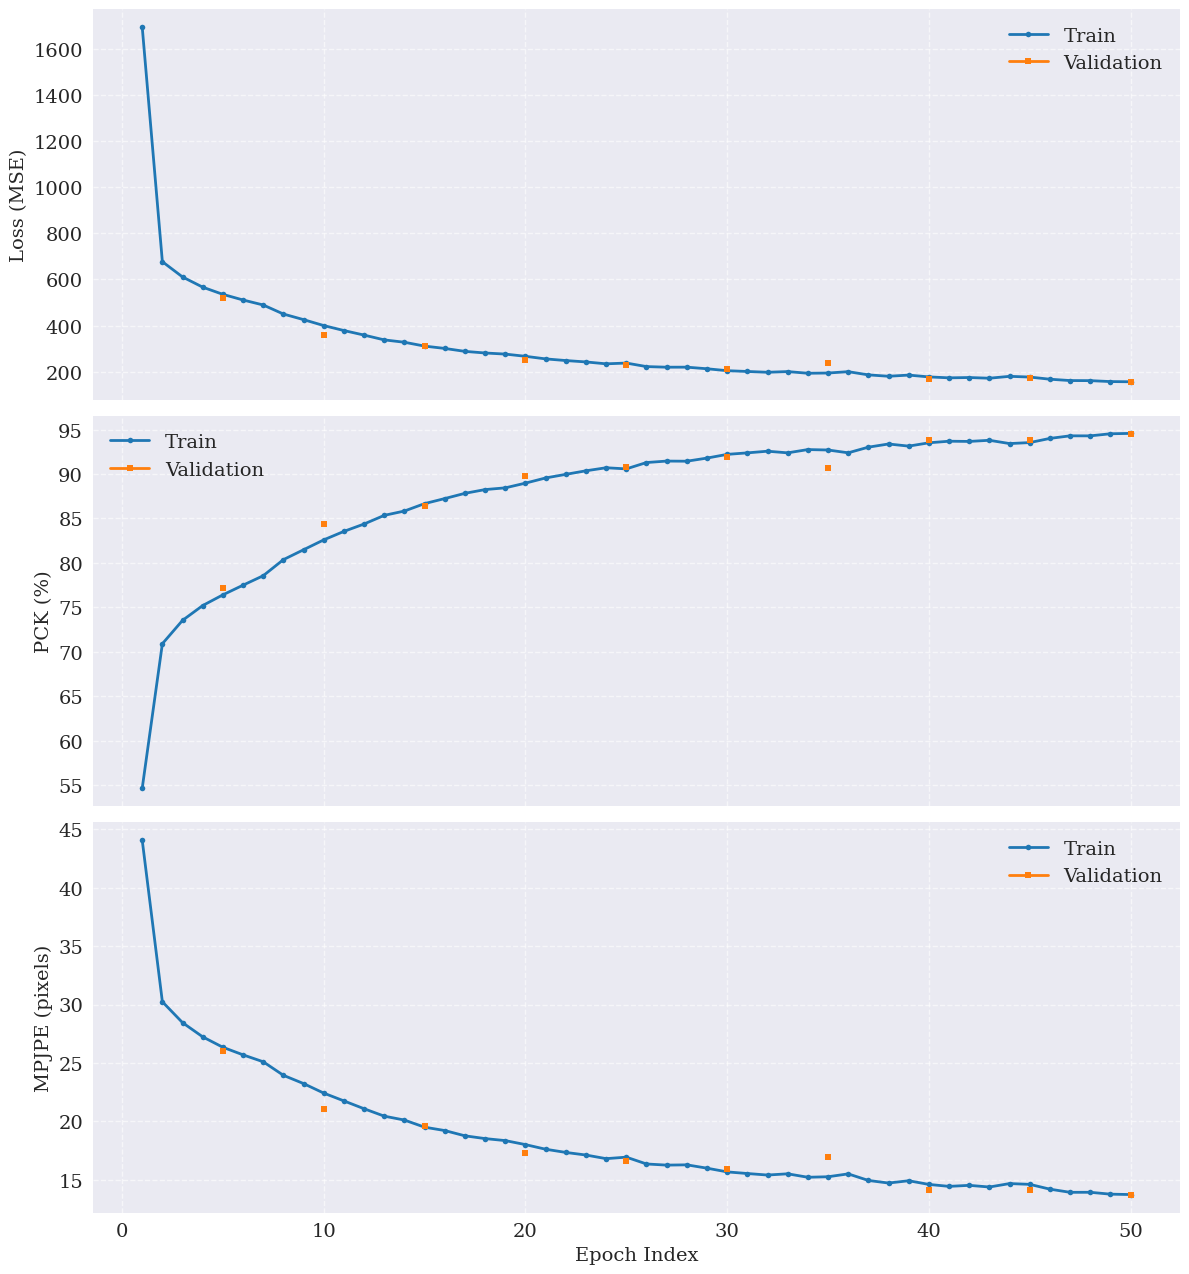

In [ ]:
# Plot loss, PCK, and MPJPE
fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)
# fig.suptitle('Training Metrics Dashboard', fontsize=16, fontweight='bold')

colors_train = '#1f77b4'  # Blue
colors_val = '#ff7f0e'    # Orange

def maybe_plot(ax, col_train, col_val, ylabel, title):
    if col_train in metrics_df:
        ax.plot(metrics_df['epoch_idx'], metrics_df[col_train], label='Train', marker='o', color=colors_train, linewidth=2, markersize=4)
    if col_val in metrics_df:
        ax.plot(metrics_df['epoch_idx'], metrics_df[col_val], label='Validation', marker='s', color=colors_val, linewidth=2, markersize=4)
    ax.set_ylabel(ylabel, fontsize=14)
    #ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.tick_params(axis='both', which='major', labelsize=14)

maybe_plot(axes[0], 'loss_train', 'loss_val', 'Loss (MSE)', 'Training and Validation Loss')
maybe_plot(axes[1], 'pck_train', 'pck_val', 'PCK (%)', 'Percentage of Correct Keypoints')
maybe_plot(axes[2], 'mpjpe_train', 'mpjpe_val', 'MPJPE (pixels)', 'Mean Per Joint Position Error')

axes[2].set_xlabel('Epoch Index', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
# Summaries: best val metrics and checkpoint listing
summary_rows = []
if 'loss_val' in metrics_df:
    idx = metrics_df['loss_val'].idxmin()
    summary_rows.append({'metric': 'loss_val', 'best': metrics_df.loc[idx, 'loss_val'], 'epoch_idx': metrics_df.loc[idx, 'epoch_idx']})
if 'pck_val' in metrics_df:
    idx = metrics_df['pck_val'].idxmax()
    summary_rows.append({'metric': 'pck_val', 'best': metrics_df.loc[idx, 'pck_val'], 'epoch_idx': metrics_df.loc[idx, 'epoch_idx']})
if 'mpjpe_val' in metrics_df:
    idx = metrics_df['mpjpe_val'].idxmin()
    summary_rows.append({'metric': 'mpjpe_val', 'best': metrics_df.loc[idx, 'mpjpe_val'], 'epoch_idx': metrics_df.loc[idx, 'epoch_idx']})

if summary_rows:
    display(pd.DataFrame(summary_rows))
else:
    print('No validation metrics to summarize.')

ckpt_dir = run_path / 'checkpoints'
if ckpt_dir.exists():
    ckpts = sorted(ckpt_dir.glob('*.ckpt'), key=lambda p: p.stat().st_mtime)
    if ckpts:
        print('Checkpoints (newest last):')
        for p in ckpts:
            print(' -', p.name)
    else:
        print('No .ckpt files found in checkpoints/.')
else:
    print('No checkpoints directory found for this run.')

,metric,best,epoch_idx
0,loss_val,157.428314,50
1,pck_val,94.521622,50
2,mpjpe_val,13.683167,50


Checkpoints (newest last):
 - epoch=49-step=19400.ckpt


Loading model from: /home/dberretta-iit.local/Documents/Repos/GraphEnet-v2/lightning_logs/scarf_dataset_test20251218/version_0/checkpoints/epoch=49-step=19400.ckpt
Running inference on: cuda


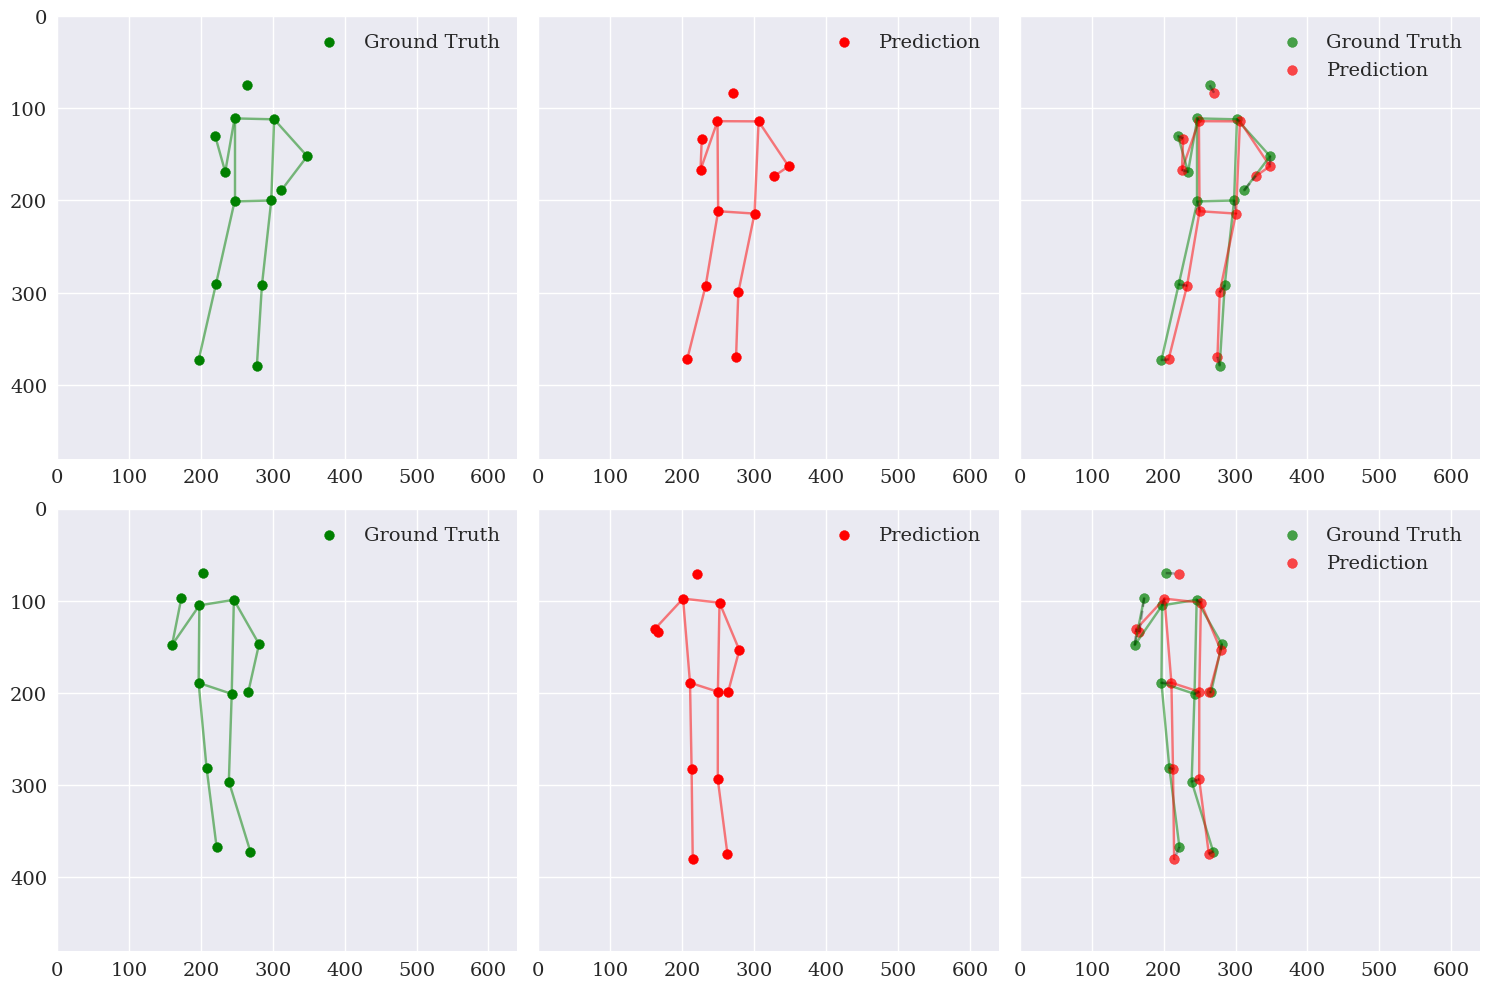

Displayed pose predictions on validation samples. Green: ground truth, Red: predictions.


In [ ]:
# Video Visualization on Validation Set
import torch
import pytorch_lightning as pl
from torch_geometric.loader import DataLoader
from graph_enet.data.scarfDataset_splineConv import scarfDataset_splineConv
from graph_enet.hpe_gnn.model.hpegnn import hpeGnn_splineConv_single_weight
from graph_enet.utils.fixed_metrics import pck_error, mpjpe_error

# Monkey patch metrics
import graph_enet.hpe_gnn.utils.metrics
graph_enet.hpe_gnn.utils.metrics.pck_error = pck_error
graph_enet.hpe_gnn.utils.metrics.mpjpe_error = mpjpe_error

# Find the latest checkpoint
ckpt_dir = run_path / 'checkpoints'
if ckpt_dir.exists():
    ckpts = sorted(ckpt_dir.glob('*.ckpt'), key=lambda p: p.stat().st_mtime)
    if ckpts:
        latest_ckpt = ckpts[-1]
        print(f"Loading model from: {latest_ckpt}")
        
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Running inference on: {device}")
        
        # Load model
        model = hpeGnn_splineConv_single_weight.load_from_checkpoint(str(latest_ckpt), map_location=device)
        model.to(device)
        model.eval()
        
        # Load validation dataset
        val_dataset = scarfDataset_splineConv(
            '/home/dberretta-iit.local/data/new_scarfGNN_val',
            rf_size=14, alpha=1.0, C=0.3, res=(640, 480)
        )
        val_dataset = val_dataset.shuffle()
        
        # Create dataloader
        val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)
        
        # Get a few samples
        num_samples = 2
        samples = []
        for i, batch in enumerate(val_loader):
            if i >= num_samples:
                break
            samples.append(batch)
        
        # Define skeleton connections
        skeleton_connections = [
            (1, 2), (1, 3), (1, 6), (2, 4), (2, 5), (3, 7), (4, 8), (5, 6), (5, 10), (6, 9), (9, 11), (10, 12)
        ]
        
        # Visualize predictions
        fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5*num_samples))
        if num_samples == 1:
            axes = axes.reshape(1, -1)
        
        for i, batch in enumerate(samples):
            batch = batch.to(device)
            with torch.no_grad():
                pred, _ = model.forward(batch.x, batch.edge_index, batch.edge_attr, batch.pos, batch.batch)
                y_true = torch.reshape(batch.y, (batch.num_graphs, -1))
                
                pred_joints = pred.reshape(-1, 2).cpu().numpy()
                gt_joints = y_true.reshape(-1, 2).cpu().numpy()
                
                # Ground truth
                axes[i, 0].scatter(gt_joints[:, 0], gt_joints[:, 1], c='green', s=50, label='Ground Truth')
                for conn in skeleton_connections:
                    start, end = conn
                    if start < len(gt_joints) and end < len(gt_joints):
                        axes[i, 0].plot([gt_joints[start, 0], gt_joints[end, 0]], 
                                       [gt_joints[start, 1], gt_joints[end, 1]], 'g-', alpha=0.5)
                # axes[i, 0].set_title(f'Sample {i+1}: Ground Truth')
                axes[i, 0].set_xlim(0, 640)
                axes[i, 0].set_ylim(0, 480)
                axes[i, 0].invert_yaxis()
                axes[i, 0].legend()
                
                # Prediction
                axes[i, 1].scatter(pred_joints[:, 0], pred_joints[:, 1], c='red', s=50, label='Prediction')
                for conn in skeleton_connections:
                    start, end = conn
                    if start < len(pred_joints) and end < len(pred_joints):
                        axes[i, 1].plot([pred_joints[start, 0], pred_joints[end, 0]], 
                                       [pred_joints[start, 1], pred_joints[end, 1]], 'r-', alpha=0.5)
                # axes[i, 1].set_title(f'Sample {i+1}: Prediction')
                axes[i, 1].set_xlim(0, 640)
                axes[i, 1].set_ylim(0, 480)
                axes[i, 1].invert_yaxis()
                axes[i, 1].legend()
                axes[i, 1].set_yticklabels([])
                
                # Overlay
                axes[i, 2].scatter(gt_joints[:, 0], gt_joints[:, 1], c='green', s=50, label='Ground Truth', alpha=0.7)
                axes[i, 2].scatter(pred_joints[:, 0], pred_joints[:, 1], c='red', s=50, label='Prediction', alpha=0.7)
                for conn in skeleton_connections:
                    start, end = conn
                    if start < len(gt_joints) and end < len(gt_joints):
                        axes[i, 2].plot([gt_joints[start, 0], gt_joints[end, 0]], 
                                       [gt_joints[start, 1], gt_joints[end, 1]], 'g-', alpha=0.5)
                    if start < len(pred_joints) and end < len(pred_joints):
                        axes[i, 2].plot([pred_joints[start, 0], pred_joints[end, 0]], 
                                       [pred_joints[start, 1], pred_joints[end, 1]], 'r-', alpha=0.5)
                # Error lines
                for j in range(len(gt_joints)):
                    axes[i, 2].plot([gt_joints[j, 0], pred_joints[j, 0]], 
                                   [gt_joints[j, 1], pred_joints[j, 1]], 'k--', alpha=0.3)
                pck = pck_error(y_true, pred, batch.th_pck, model.pck_multiplier).item()
                mpjpe = mpjpe_error(y_true, pred).item()
                # axes[i, 2].set_title(f'Sample {i+1}: Comparison (MPJPE: {mpjpe:.1f}px)')
                axes[i, 2].set_xlim(0, 640)
                axes[i, 2].set_ylim(0, 480)
                axes[i, 2].invert_yaxis()
                axes[i, 2].legend()
                axes[i, 2].set_yticklabels([])
        
        plt.tight_layout()
        plt.show()
        
        print("Displayed pose predictions on validation samples. Green: ground truth, Red: predictions.")
    else:
        print("No checkpoints found.")
else:
    print("No checkpoints directory found.")

In [ ]:
# Animated Video Visualization on Validation Set
import torch
import pytorch_lightning as pl
from torch_geometric.loader import DataLoader
from graph_enet.data.scarfDataset_splineConv import scarfDataset_splineConv
from graph_enet.hpe_gnn.model.hpegnn import hpeGnn_splineConv_single_weight
from graph_enet.utils.fixed_metrics import pck_error, mpjpe_error
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
import matplotlib.pyplot as plt

# Monkey patch metrics
import graph_enet.hpe_gnn.utils.metrics
graph_enet.hpe_gnn.utils.metrics.pck_error = pck_error
graph_enet.hpe_gnn.utils.metrics.mpjpe_error = mpjpe_error

# Find the latest checkpoint
ckpt_dir = run_path / 'checkpoints'
if ckpt_dir.exists():
    ckpts = sorted(ckpt_dir.glob('*.ckpt'), key=lambda p: p.stat().st_mtime)
    if ckpts:
        latest_ckpt = ckpts[-1]
        print(f"Loading model from: {latest_ckpt}")
        
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Running inference on: {device}")

        # Load model
        model = hpeGnn_splineConv_single_weight.load_from_checkpoint(str(latest_ckpt), map_location=device)
        model.to(device)
        model.eval()
        
        # Load validation dataset
        val_dataset = scarfDataset_splineConv(
            '/home/dberretta-iit.local/data/new_scarfGNN_val',
            rf_size=14, alpha=1.0, C=0.3, res=(640, 480)
        )
        val_dataset = val_dataset.shuffle()
        
        # Create dataloader
        val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)
        
        # Get more samples for animation
        num_samples = 20  # Increase for longer video
        samples = []
        predictions = []
        ground_truths = []
        pck_scores = []
        mpjpe_scores = []
        th_pck_list = []
        
        for i, batch in enumerate(val_loader):
            if i >= num_samples:
                break
            
            batch = batch.to(device)
            
            with torch.no_grad():
                pred, _ = model.forward(batch.x, batch.edge_index, batch.edge_attr, batch.pos, batch.batch)
                y_true = torch.reshape(batch.y, (batch.num_graphs, -1))
                
                pred_joints = pred.reshape(-1, 2).cpu().numpy()
                gt_joints = y_true.reshape(-1, 2).cpu().numpy()
                
                pck = pck_error(y_true, pred, batch.th_pck, model.pck_multiplier).item()
                mpjpe = mpjpe_error(y_true, pred).item()
                
                samples.append(batch.cpu())
                predictions.append(pred_joints)
                ground_truths.append(gt_joints)
                pck_scores.append(pck)
                mpjpe_scores.append(mpjpe)
                th_pck_list.append(batch.th_pck.item())
        
        # Define skeleton connections
        skeleton_connections = [
            (1, 2), (1, 3), (1, 6), (2, 4), (2, 5), (3, 7), (4, 8), (5, 6), (5, 10), (6, 9), (9, 11), (10, 12)
        ]
        
        # Create animation
        fig, ax = plt.subplots(figsize=(8, 6))
        
        def init():
            ax.clear()
            ax.set_xlim(0, 640)
            ax.set_ylim(0, 480)
            ax.invert_yaxis()
            ax.set_title('Pose Prediction Animation')
            return []
        
        def animate(frame):
            ax.clear()
            pred_joints = predictions[frame]
            gt_joints = ground_truths[frame]
            pck = pck_scores[frame]
            mpjpe = mpjpe_scores[frame]
            th = th_pck_list[frame]
            
            # Plot ground truth
            ax.scatter(gt_joints[:, 0], gt_joints[:, 1], c='green', s=50, label='Ground Truth', alpha=0.7)
            for conn in skeleton_connections:
                start, end = conn
                if start < len(gt_joints) and end < len(gt_joints):
                    ax.plot([gt_joints[start, 0], gt_joints[end, 0]], 
                           [gt_joints[start, 1], gt_joints[end, 1]], 'g-', alpha=0.5)
            
            # Plot prediction
            ax.scatter(pred_joints[:, 0], pred_joints[:, 1], c='red', s=50, label='Prediction', alpha=0.7)
            for conn in skeleton_connections:
                start, end = conn
                if start < len(pred_joints) and end < len(pred_joints):
                    ax.plot([pred_joints[start, 0], pred_joints[end, 0]], 
                           [pred_joints[start, 1], pred_joints[end, 1]], 'r-', alpha=0.5)
            
            # Error lines
            for j in range(len(gt_joints)):
                ax.plot([gt_joints[j, 0], pred_joints[j, 0]], 
                       [gt_joints[j, 1], pred_joints[j, 1]], 'k--', alpha=0.3)
            
            ax.set_xlim(0, 640)
            ax.set_ylim(0, 480)
            ax.invert_yaxis()
            ax.set_title(f'Sample {frame+1}/{num_samples}: PCK={pck:.3f}, MPJPE={mpjpe:.1f}px, Th={th:.1f}')
            ax.legend()
            return []
        
        anim = FuncAnimation(fig, animate, init_func=init, frames=num_samples, interval=500, blit=False)
        plt.close(fig)
        
        # Display animation in notebook
        print(f"Animation created with {num_samples} frames. Green: ground truth, Red: predictions, Black dashed: errors.")
        display(HTML(anim.to_jshtml()))
    else:
        print("No checkpoints found.")
else:
    print("No checkpoints directory found.")

Loading model from: /home/dberretta-iit.local/Documents/Repos/GraphEnet-v2/lightning_logs/scarf_dataset_test20251218/version_0/checkpoints/epoch=49-step=19400.ckpt
Running inference on: cuda
Animation created with 20 frames. Green: ground truth, Red: predictions, Black dashed: errors.
